In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn

data_dir = '../../../data/mujoco/hopper'
model_dir = '../../../models/mujoco/hopper'
result_dir = '../../../results/mujoco/hopper'

data_suffix = '2x'

### Creating baseline dataset

In [2]:
data_nsample = 918
data = util_data.read_datafile(f'{data_dir}/baseline_{data_suffix}', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 11
act_ndim = 3
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataloaders = []
nmodel = 7

for _ in range(nmodel):
    dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
    dataloaders.append(torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True))


read data shape: torch.Size([80, 918, 14])
read observations shape: torch.Size([80, 918, 11])
read actions shape: torch.Size([80, 918, 3])
shape of observations for training: torch.Size([80, 917, 11])
shape of next observations for training: torch.Size([80, 917, 11])
shape of actions for training: torch.Size([80, 917, 3])


### Training ensemble dynamics

In [3]:
model = example_mujoco.model_ensemble(nmodel, obs_ndim, act_ndim)
example_mujoco.train_ensemble(model, dataloaders, nepoch=300)

0 [array([-0.05528714]), array([-0.05866946]), array([-0.05854561]), array([-0.05995592]), array([-0.05798775]), array([-0.05573454]), array([-0.05942944])]
10 [array([-0.16960205]), array([-0.20769446]), array([-0.20227749]), array([-0.21139218]), array([-0.20121879]), array([-0.18722572]), array([-0.20784472])]
20 [array([-0.46348844]), array([-0.4756343]), array([-0.49248552]), array([-0.43021376]), array([-0.4792114]), array([-0.46927091]), array([-0.47691679])]
30 [array([-0.5942876]), array([-0.58079161]), array([-0.57213177]), array([-0.57121662]), array([-0.56091659]), array([-0.58610099]), array([-0.60272653])]
40 [array([-0.61250966]), array([-0.63987405]), array([-0.65792295]), array([-0.63676282]), array([-0.35494726]), array([-0.64235674]), array([-0.63385739])]
50 [array([-0.48497088]), array([-0.66243315]), array([-0.65778521]), array([-0.55849825]), array([-0.60832964]), array([-0.6601615]), array([-0.68739898])]
60 [array([-0.69962958]), array([-0.58268206]), array([-0

In [4]:
# --! compute model capacity

nparam = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of trainable parameters in model ensemble: {nparam/1e6}M')

number of trainable parameters in model ensemble: 0.527156M


# Evaluating ensemble baseline

In [5]:
eval_data = util_data.read_datafile(f'{data_dir}/eval', data_nsample)
print(f'read evaluation data shape: {eval_data.shape}')

eval_obs, eval_act = torch.split(eval_data, [obs_ndim, act_ndim], dim=-1)
print(f'read evaluation observations shape: {eval_obs.shape}')
print(f'read evaluation actions shape: {eval_act.shape}')

# --! normalize evaluation data
eval_obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

model.eval()

read evaluation data shape: torch.Size([30, 918, 14])
read evaluation observations shape: torch.Size([30, 918, 11])
read evaluation actions shape: torch.Size([30, 918, 3])


In [25]:
this_traj = 7
deterministic = False
reanchor_nsample = 1_000_000 # ensure no re-anchoring

s0 = eval_obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_ensemble(
    model, s0,
    eval_obs[this_traj], eval_act[this_traj],
    deterministic=deterministic, reanchor_nsample=reanchor_nsample)
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 11])


### Plotting rollout results

In [26]:
def disp_rollout(obs_true, obs_rollout, obs_mean, obs_std, this_traj=0, disp_end=300):

    with torch.no_grad():
        plot_rollout_traj = torch.unsqueeze(obs_rollout, 0)
        plot_rollout_traj = torch.cat([
            example_mujoco.denormalize_standard(
                s, mean, std) for s, mean, std in zip(torch.split(plot_rollout_traj, 1, dim=-1), obs_mean, obs_std)], dim=-1)
        plot_obs = torch.cat([
            example_mujoco.denormalize_standard(
                s, mean, std) for s, mean, std in zip(torch.split(obs_true, 1, dim=-1), obs_mean, obs_std)], dim=-1)

        plot_rollout_traj[:, 410:, :1] = 5.0
        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(plot_obs[this_traj, :disp_end, 0], label='z')
        plt.plot(plot_rollout_traj[0, :disp_end, 0])
        plt.ylim((-1,3))
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(plot_obs[this_traj, :disp_end, 9], label='dz')
        plt.plot(plot_rollout_traj[0, :disp_end, 9])
        plt.legend()

        plt.show()

    return plot_obs, plot_rollout_traj

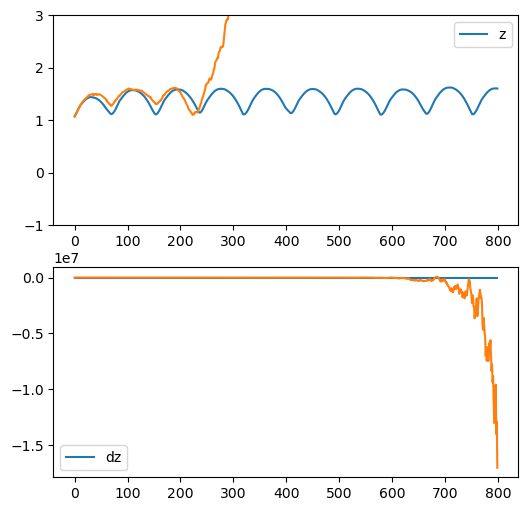

In [28]:
disp_end = 800
datasaved = False

plot_obs, plot_rollout = disp_rollout(eval_obs, rollout_traj, obs_mean, obs_std, this_traj, disp_end)

if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_step = torch.arange(eval_obs.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :disp_end, :1],
        plot_obs[:1, :disp_end, :1], plot_obs[:1, :disp_end, [6]],
        plot_rollout[:1, :disp_end, :1], plot_rollout[:1, :disp_end, [6]]], axis=2)
    util_data.write_datafile(f'{result_dir}/ensemble_rollout_{data_suffix}_{rollout_type}_{nmodel}', savedata, delim=' ')

### Analyzing mse vs. rollout horizon

In [29]:
# --! compute MSE vs. horizon

traj_mse = []
with torch.no_grad():
    for j in range(eval_obs.shape[0]): # trajectory
        print(f'processing trajectory {j+1} out of {eval_obs.shape[0]}')
        mse = []
        for h in range(1, eval_obs.shape[1]): # horizon
            s0 = eval_obs[j, 0]
            cmp_rollout = example_mujoco.rollout_ensemble(
                model, s0,
                eval_obs[j, :h], eval_act[j, :h],
                deterministic=deterministic, reanchor_nsample=reanchor_nsample)

            # --! denormalize results
            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(eval_obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)

            # --! compute error
            loss = F.mse_loss(cmp_rollout, cmp_obs)
            mse.append(loss)
            if h % 100 == 0:
                print(f'\thorizon {h} out of {eval_obs.shape[1]}, loss: {loss}')
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)

processing trajectory 1 out of 30
	horizon 100 out of 918, loss: 0.6383349895477295
	horizon 200 out of 918, loss: 9.112083435058594
	horizon 300 out of 918, loss: 24.187301635742188
	horizon 400 out of 918, loss: 107249.890625
	horizon 500 out of 918, loss: 74156528.0
	horizon 600 out of 918, loss: 952788096.0
	horizon 700 out of 918, loss: 42946456.0
	horizon 800 out of 918, loss: 55045043257344.0
	horizon 900 out of 918, loss: 1.2600259372908544e+16
processing trajectory 2 out of 30
	horizon 100 out of 918, loss: 0.4270448088645935
	horizon 200 out of 918, loss: 20.531198501586914
	horizon 300 out of 918, loss: 2560.980712890625
	horizon 400 out of 918, loss: 227916.671875
	horizon 500 out of 918, loss: 431028.6875
	horizon 600 out of 918, loss: 75638423552.0
	horizon 700 out of 918, loss: 584763047936.0
	horizon 800 out of 918, loss: 7653083039399936.0
	horizon 900 out of 918, loss: 4.290774548925645e+16
processing trajectory 3 out of 30
	horizon 100 out of 918, loss: 3.25548911094

tensor(0.0142)
tensor(0.0165)


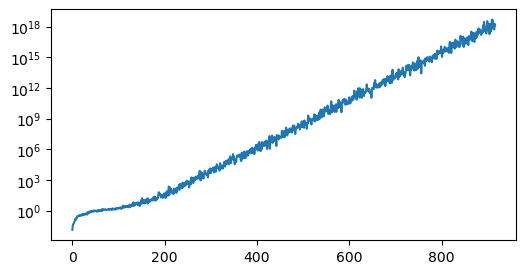

In [31]:
# --! plot MSE vs. horizon

traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.show()

datasaved = False
if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/ensemble_mse_{data_suffix}_{rollout_type}_{nmodel}', savedata, delim=' ')